* Step 2: Dataset Loading & Exploratory Data Analysis

Load csv using pandas.


In [2]:
import pandas as pd

df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
# df.head()

Print .shape, .info(), .describe(), and .head()

In [3]:
print('Shape:',df.shape)

Shape: (7043, 21)


In [4]:
print('Info: ',df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print('Describe: ',df.describe())

Describe:         SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [6]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Convert TotalCharges from object to float

In [7]:
df['TotalCharges'].dtype

dtype('O')

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


Churn percentage

In [9]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Handle missing values

In [11]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median)
df.isnull().sum()
# df['Churn'].isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

* 2.2  Univariate Analysis

Plot a countplot of the target variable Churn.

<Axes: xlabel='Churn', ylabel='count'>

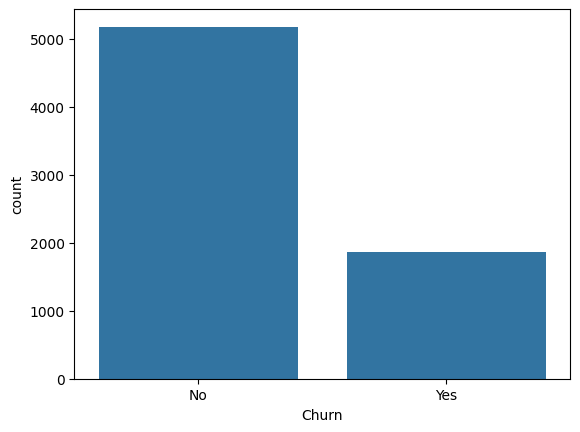

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df,x='Churn')

Plot histograms for: tenure, MonthlyCharges.

Text(0.5, 0, 'tenure')

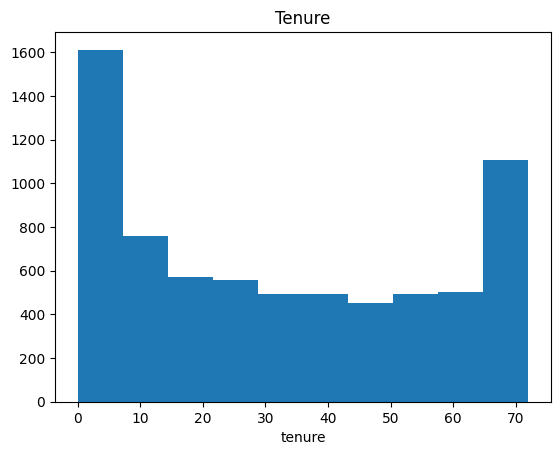

In [13]:
plt.hist(df['tenure'])
plt.title('Tenure')
plt.xlabel('tenure')

Text(0.5, 0, 'MonthlyCharges')

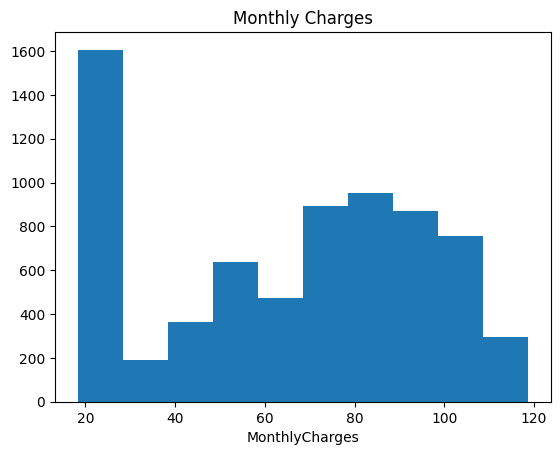

In [14]:
plt.hist(df['MonthlyCharges'])
plt.title('Monthly Charges')
plt.xlabel('MonthlyCharges')

Plot countplots for key categorical features: Contract, InternetService, PaymentMethod

Text(0.5, 0, 'Contract')

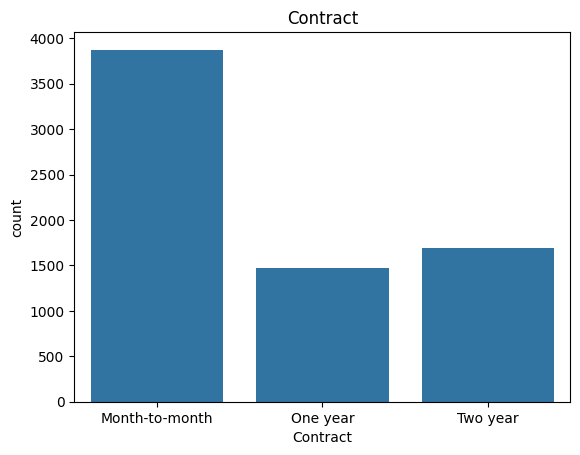

In [15]:
sns.countplot(data=df,x='Contract')
plt.title('Contract')
plt.xlabel('Contract')

Text(0.5, 0, 'InternetService')

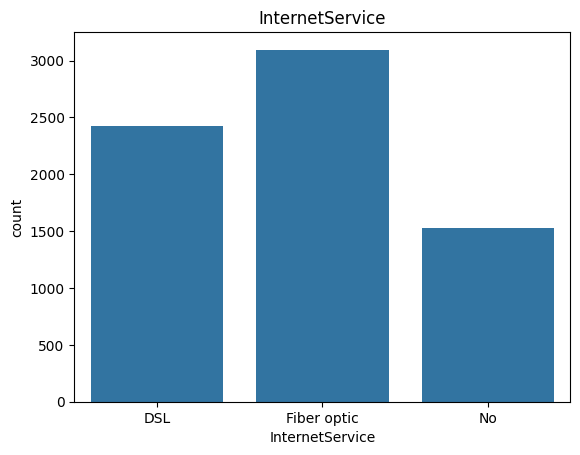

In [16]:
sns.countplot(data=df,x='InternetService')
plt.title('InternetService')
plt.xlabel('InternetService')

Text(0.5, 0, 'PaymentMethod')

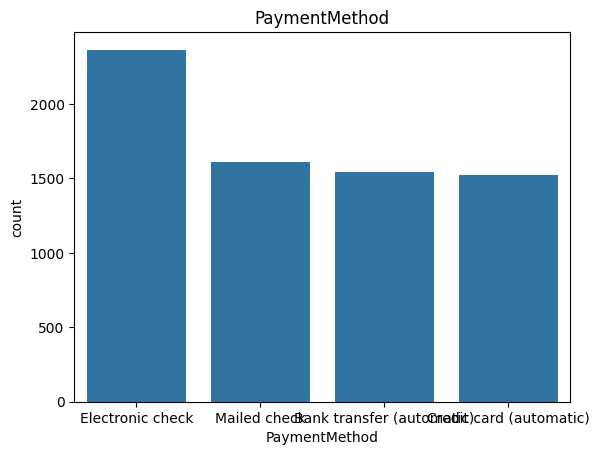

In [17]:
sns.countplot(data=df,x='PaymentMethod')
plt.title('PaymentMethod')
plt.xlabel('PaymentMethod')

* 2.3  Bivariate Analysis

Churn rate by Contract type — which contract type churns the most? Plot a grouped bar chart

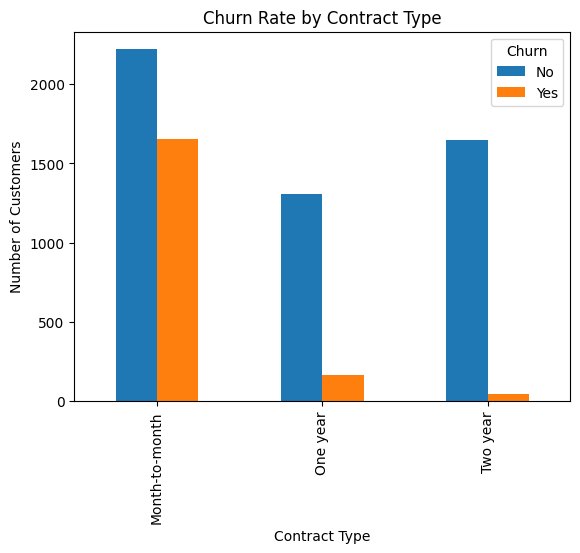

In [18]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])
contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title="Churn")
plt.show()

### Here month-to-month contract customers churn most 

Churn rate by tenure bucket (bin tenure into 0–12, 13–24, 25–48, 49–72 months). Plot a bar chart

C:\Users\adity\AppData\Local\Temp\ipykernel_7916\3409616117.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Tenure_Bucket')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='Churn Rate (%)')


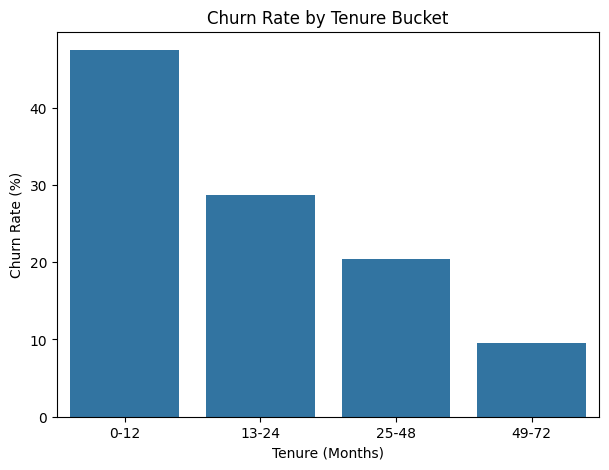

In [19]:
df['Tenure_Bucket'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49-72'],
    include_lowest=True
)

churn_rate = (
    df.groupby('Tenure_Bucket')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='Churn Rate (%)')
)

plt.figure(figsize=(7,5))
sns.barplot(data=churn_rate,x='Tenure_Bucket',y='Churn Rate (%)')

plt.title('Churn Rate by Tenure Bucket')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.show()

Boxplot: MonthlyCharges vs Churn

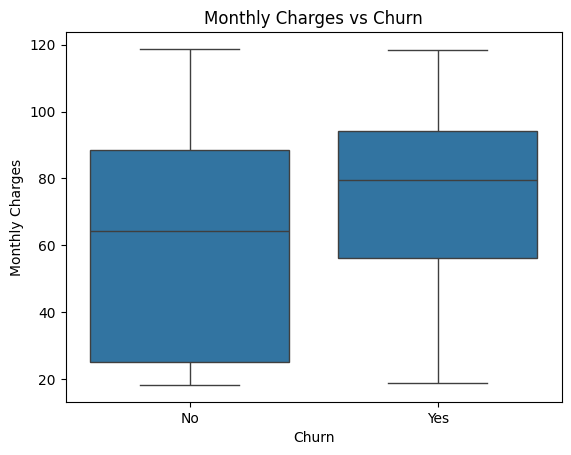

In [20]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)

plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

## Yes here chuners pay more monthly

Heatmap: Correlation matrix of all numerical features. Note any strong correlations.


Text(0.5, 1.0, 'Correlation Matrix')

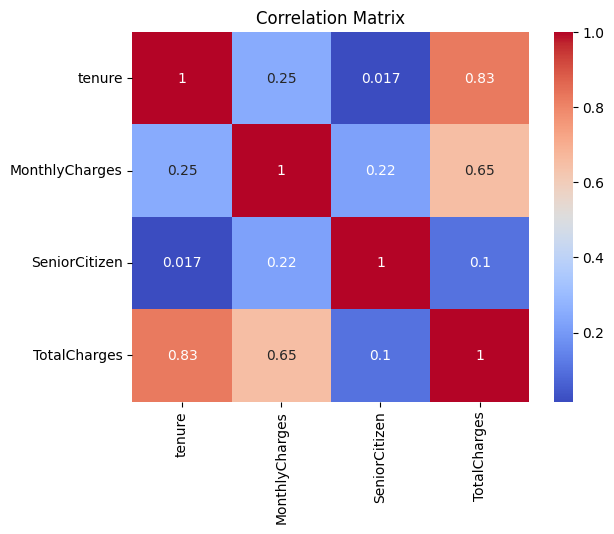

In [21]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
num_cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen', 'TotalCharges']
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')

### -Tenure & TotalCharges has stong positive correlation - 0.83. Customers who stay longer has high total charges.
### - Senior citizen & tenure has weak correlation - 0.017

* Step 3: Data Preprocessing & Feature Engineering

3.1  Drop & Clean 

Drop the customerID column (unique identifier, no predictive value).


In [22]:
df=df.drop('customerID',axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Bucket
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12


Handle the TotalCharges nulls/whitespace identified in Step 2 — fill with median.

In [23]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].dtype
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Tenure_Bucket       0
dtype: int64

* 3.2  Feature Engineering

Create tenure_group: bin tenure into 4 groups — 'New' (0–12), 'Mid' (13–36), 'Senior' (37–60), 'Loyal' (61+).

In [24]:
bins = [0, 12, 36, 60, float('inf')]
labels = ['New', 'Mid', 'Senior', 'Loyal']

df['tenure_group'] = pd.cut(df['tenure'],bins=bins,labels=labels,include_lowest=True)
df['tenure_group'],print(),print(),df['tenure_group'].value_counts()

(0          New
 1          Mid
 2          New
 3       Senior
 4          New
          ...  
 7038       Mid
 7039     Loyal
 7040       New
 7041       New
 7042     Loyal
 Name: tenure_group, Length: 7043, dtype: category
 Categories (4, object): ['New' < 'Mid' < 'Senior' < 'Loyal'],
 None,
 None,
 tenure_group
 New       2186
 Mid       1856
 Senior    1594
 Loyal     1407
 Name: count, dtype: int64)

Create num_services: count the number of add-on services each customer subscribes to (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies — count 'Yes' values).

In [25]:
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)
df['num_services']

0       1
1       2
2       2
3       3
4       0
       ..
7038    5
7039    4
7040    1
7041    0
7042    5
Name: num_services, Length: 7043, dtype: int64

Create AutoPay: 1 if PaymentMethod contains 'automatic', else 0

In [26]:
df['autopay']=df['PaymentMethod'].str.contains('automatic').astype(int)
df[['PaymentMethod', 'autopay']].head(10)

,PaymentMethod,autopay
0,Electronic check,0
1,Mailed check,0
2,Mailed check,0
3,Bank transfer (automatic),1
4,Electronic check,0
5,Electronic check,0
6,Credit card (automatic),1
7,Mailed check,0
8,Electronic check,0
9,Bank transfer (automatic),1


* 3.3  Encoding

Binary columns (Partner, Dependents, PhoneService, PaperlessBilling, Churn, etc.) — map Yes→1, No→0.

In [27]:
binary_cols=df[['Partner','Dependents','PhoneService','PaperlessBilling','Churn']]

from sklearn.preprocessing import OrdinalEncoder
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
encoder = OrdinalEncoder(categories=[["No", "Yes"]] * len(binary_cols))
df[binary_cols] = encoder.fit_transform(df[binary_cols]).astype(int)

In [28]:
df[binary_cols].head()

,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,1,0,0,1,0
1,0,0,1,0,0
2,0,0,1,1,1
3,0,0,0,0,0
4,0,0,1,1,1


Apply One-Hot Encoding to: InternetService, Contract, PaymentMethod

In [29]:
df=pd.get_dummies(df,columns=['InternetService', 'Contract', 'PaymentMethod'],drop_first=True,dtype=int)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,tenure_group,num_services,autopay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,Female,0,1,0,1,0,No phone service,No,Yes,No,...,New,1,0,0,0,0,0,0,1,0
1,Male,0,0,0,34,1,No,Yes,No,Yes,...,Mid,2,0,0,0,1,0,0,0,1
2,Male,0,0,0,2,1,No,Yes,Yes,No,...,New,2,0,0,0,0,0,0,0,1
3,Male,0,0,0,45,0,No phone service,Yes,No,Yes,...,Senior,3,1,0,0,1,0,0,0,0
4,Female,0,0,0,2,1,No,No,No,No,...,New,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,1,1,24,1,Yes,Yes,No,Yes,...,Mid,5,0,0,0,1,0,0,0,1
7039,Female,0,1,1,72,1,Yes,No,Yes,Yes,...,Loyal,4,1,1,0,1,0,1,0,0
7040,Female,0,1,1,11,0,No phone service,Yes,No,No,...,New,1,0,0,0,0,0,0,1,0
7041,Male,1,1,0,4,1,Yes,No,No,No,...,New,0,0,1,0,0,0,0,0,1


Apply Label Encoding to: tenure_group (preserving ordinal order)

In [30]:
order = {'New': 0,'Mid': 1,'Senior': 2,'Loyal': 3}

df['tenure_group'] = df['tenure_group'].map(order)
print(df['tenure_group'].head(5))

0    0
1    1
2    0
3    2
4    0
Name: tenure_group, dtype: category
Categories (4, int64): [0 < 1 < 2 < 3]


Drop original columns that have been replaced by engineered features

In [31]:
df.drop(columns=service_cols, inplace=True)

3.4 Scaling:- 

-Apply StandardScaler to: tenure, MonthlyCharges, TotalCharges, num_services. 

-Note: KNN and SVM are distance-based — scaling is critical. Decision Tree and Naive Bayes are not — but scale all features uniformly for a fair comparison.


In [32]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scale_cols = ['tenure','MonthlyCharges','TotalCharges','num_services']

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print(X_train.head())
print(X_test.head())

      gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
3738    Male              0        0           0  0.102371             0   
3151    Male              0        1           1 -0.711743             1   
4860    Male              0        1           1 -0.793155             0   
3867  Female              0        1           0 -0.263980             1   
3810    Male              0        1           1 -1.281624             1   

         MultipleLines  PaperlessBilling  MonthlyCharges  TotalCharges  ...  \
3738  No phone service                 0       -0.521976     -0.263289  ...   
3151                No                 0        0.337478     -0.504814  ...   
4860  No phone service                 0       -0.809013     -0.751213  ...   
3867                No                 1        0.284384     -0.173699  ...   
3810                No                 0       -0.676279     -0.990851  ...   

     tenure_group num_services  autopay  InternetService_Fiber optic

* 3.5  Handle Class Imbalance 

-Report class counts in the training set.


In [34]:
from imblearn.over_sampling import SMOTE

print("Class counts before SMOTE:")
print(y_train.value_counts())

Class counts before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64


Apply SMOTE (from imblearn) to the training set only. Print new class counts after oversampling.

In [35]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
# df.dropna(inplace=True)
# df['TotalCharges'].isnull().sum()
# df['TotalCharges'].dtype

df['gender'] = df['gender'].map({'Female': 0,'Male': 1})
df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1,'No': 0,'No phone service': 0})
df['Tenure_Bucket']=df['Tenure_Bucket'].cat.codes
df['tenure_group'] = df['tenure_group'].astype(int)

In [36]:
scale_cols = ['tenure','MonthlyCharges','TotalCharges','num_services']

from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])


In [37]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,TotalCharges,...,tenure_group,num_services,autopay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,0,0,0,0.102371,0,0,0,-0.521976,-0.263289,...,1,0.507935,0,0,0,0,0,0,1,0
3151,1,0,1,1,-0.711743,1,0,0,0.337478,-0.504814,...,1,-0.570530,0,1,0,0,0,0,0,1
4860,1,0,1,1,-0.793155,0,0,0,-0.809013,-0.751213,...,1,0.507935,0,0,0,0,1,0,0,1
3867,0,0,1,0,-0.263980,1,0,1,0.284384,-0.173699,...,1,1.047168,1,0,0,0,1,1,0,0
3810,1,0,1,1,-1.281624,1,0,0,-0.676279,-0.990851,...,0,-1.109762,0,0,0,0,0,0,1,0


In [38]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)
print('After applying SMOTE: ')
y_train_smote.value_counts()

After applying SMOTE: 


Churn
0    4139
1    4139
Name: count, dtype: int64

* 3.6  Train-Test Split 

Split: 80% train / 20% test, stratify=y, random_state=42. 
 
Print shapes of X_train, X_test, y_train, y_test.


In [39]:
print('Shape of :')
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

Shape of :
X_train: (5634, 21)
X_test: (1409, 21)
y_train: (5634,)
y_test: (1409,)


### Step 4: Model Building — KNN & Naive Bayes


* 4.1 K-Nearest Neighbours (KNN) 

-Train KNeighborsClassifier with k=5 as baseline. Report Accuracy, Precision, Recall, F1, AUC-ROC.

In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_smote, y_train_smote)

y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:,1]

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))
print('ROC AUC :', roc_auc_score(y_test, y_prob))

Accuracy : 0.7075940383250532
Precision: 0.4665492957746479
Recall : 0.7085561497326203
F1 Score : 0.5626326963906582
ROC AUC : 0.7619184169056292


Tune k: Run a loop for k = 1, 3, 5, 7, 9, 11, 15. Plot k vs F1-Score (on validation set). which k is best?

In [41]:
import matplotlib.pyplot as plt

k_values = [1,3,5,7,9,11,15]
f1_scores = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_smote, y_train_smote)

    pred = model.predict(X_test)
    score = f1_score(y_test, pred)
    f1_scores.append(score)

print(f1_scores)

[0.4945717732207479, 0.5432639649507119, 0.5626326963906582, 0.579324462640737, 0.5888324873096447, 0.6050251256281407, 0.5988023952095808]


Plot k vs F1 Score

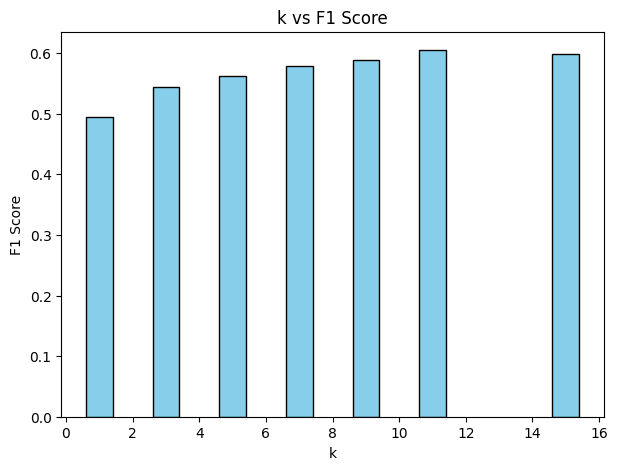

In [42]:
plt.figure(figsize=(7,5))
plt.bar(k_values, f1_scores, color='skyblue', edgecolor='black')
plt.xlabel("k")
plt.ylabel("F1 Score")
plt.title("k vs F1 Score")
plt.show()

Best k = 11, F1 Score = 0.6050251256281407

-Re-train with the optimal k. Plot Confusion Matrix heatmap

In [43]:
best_knn = KNeighborsClassifier(n_neighbors=11)

best_knn.fit(X_train_smote, y_train_smote)

y_pred = best_knn.predict(X_test)
y_prob = best_knn.predict_proba(X_test)[:,1]

Confusion Matrix Heatmap

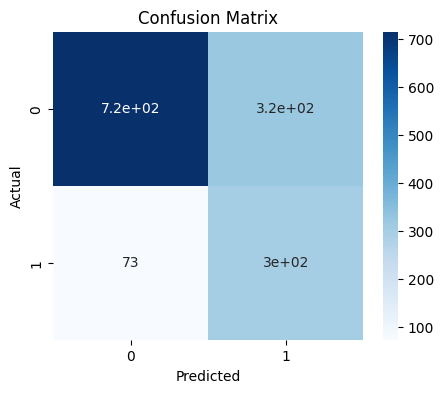

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

ROC Curve

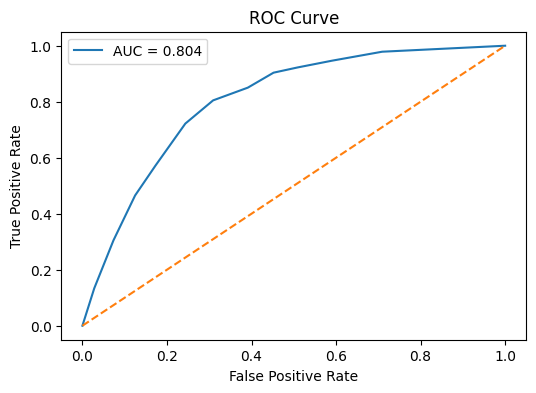

AUC = 0.8037381487509365


In [45]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

print("AUC =", roc_auc)

* 4.2  Naive Bayes — Gaussian NB 

Train GaussianNB with default parameters. Report all metrics.

In [46]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_smote, y_train_smote)

y_pred = gnb.predict(X_test)
y_prob = gnb.predict_proba(X_test)[:,1]

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision :', precision_score(y_test, y_pred))
print('Recall :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))
print('ROC AUC :', roc_auc_score(y_test, y_prob))

Accuracy : 0.7288857345635202
Precision : 0.4933993399339934
Recall : 0.7994652406417112
F1 Score : 0.610204081632653
ROC AUC : 0.8202821049368363


Print Learned Class Priors

In [47]:
print("Class Prior Probabilities:")
print(gnb.class_prior_)

Class Prior Probabilities:
[0.5 0.5]


Compare with Actual Churn Rate

In [48]:
print("Actual Class Distribution (Training Set)")
print(y_train.value_counts(normalize=True))

Actual Class Distribution (Training Set)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


Confusion Matrix Heatmap

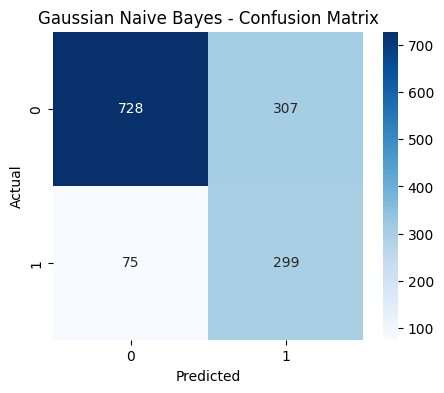

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gaussian Naive Bayes - Confusion Matrix")

plt.show()

ROC Curve

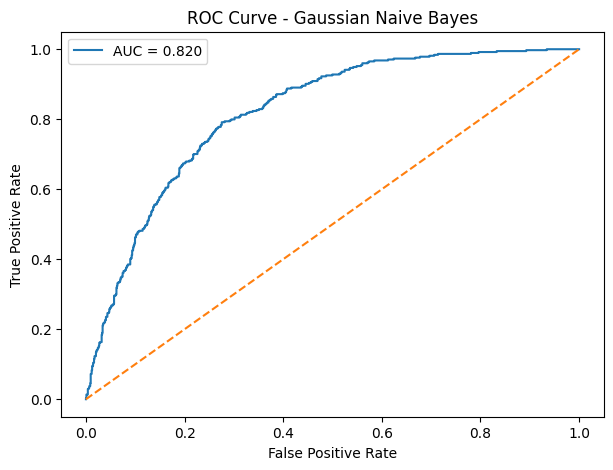

AUC = 0.8202821049368363


In [50]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gaussian Naive Bayes")

plt.legend()
plt.show()
print("AUC =", roc_auc)

* Write 2 sentences on whether this assumption holds for this dataset.


Gaussian Naive Bayes assumes that all input features are conditionally independent given the target class. In the Telco Customer Churn dataset, this assumption does not fully hold because several features, such as tenure, TotalCharges, and MonthlyCharges, are correlated, although Gaussian Naive Bayes often performs reasonably well despite this violation.

## Step 5: Model Building — SVM & Decision Tree 

* 5.1  Support Vector Machine (SVM) 

Train SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42).


In [51]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf',C=1,gamma='scale',probability=True,random_state=42)
svm.fit(X_train_smote, y_train_smote)

y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:,1]

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))
print('ROC AUC :', roc_auc_score(y_test, y_prob))

Accuracy : 0.7444996451383961
Precision: 0.5123239436619719
Recall : 0.7780748663101604
F1 Score : 0.6178343949044586
ROC AUC : 0.8243108837737994


Confusion Matrix

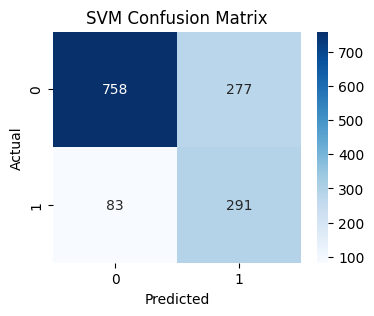

In [52]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

Tune C using 3-Fold Cross Validation

In [53]:
from sklearn.model_selection import cross_val_score

C_values = [0.1, 1, 10, 100]
mean_f1 = []

for c in C_values:
    model = SVC(kernel='rbf',C=c,gamma='scale',probability=True,random_state=42)
    scores = cross_val_score(model,X_train_smote,y_train_smote,cv=3,scoring='f1')
    mean_f1.append(scores.mean())

print(mean_f1)

[0.7746804381411909, 0.7850129200408927, 0.802611560219391, 0.8136958166239712]


Plot C vs F1

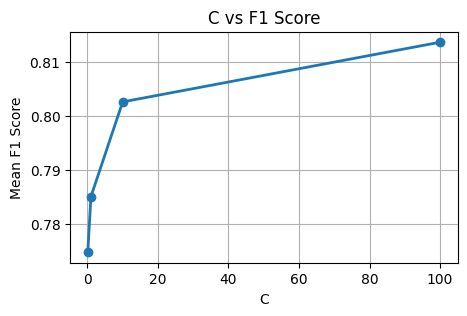

In [54]:
plt.figure(figsize=(5,3))

plt.plot(C_values,mean_f1,marker='o',linewidth=2)

plt.xlabel("C")
plt.ylabel("Mean F1 Score")
plt.title("C vs F1 Score")

plt.grid(True)
plt.show()

Select best C. 

Re-train with best C. Report final test metrics.


In [55]:
best_C = C_values[mean_f1.index(max(mean_f1))]

print("Best C =", best_C)
print("Best Mean F1 =", max(mean_f1))

best_svm = SVC(kernel='rbf',C=best_C,gamma='scale',probability=True,random_state=42)
best_svm.fit(X_train_smote, y_train_smote)

y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:,1]

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))
print('ROC AUC  :', roc_auc_score(y_test, y_prob))

Best C = 100
Best Mean F1 = 0.8136958166239712
Accuracy : 0.723207948899929
Precision: 0.4857142857142857
Recall   : 0.7272727272727273
F1 Score : 0.582441113490364
ROC AUC  : 0.7874861143403344


ROC curve.

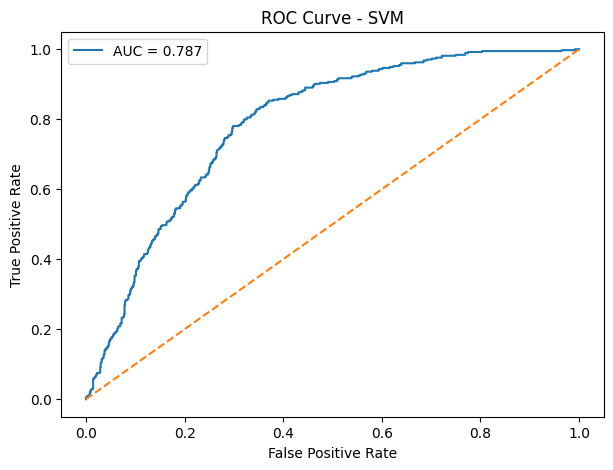

AUC = 0.7874861143403344


In [56]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")

plt.legend()
plt.show()
print("AUC =", roc_auc)

* write 2 sentences on the business tradeoff between interpretability and performance 

Support Vector Machine is considered a black-box model because it does not provide easily interpretable decision rules or feature importance. Although SVM often achieves strong predictive performance, businesses may prefer more interpretable models such as Decision Trees when understanding the reasons behind customer churn is important for decision-making

* 5.2 Decision Tree Classifier: 

-Train DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42).

In [57]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5,class_weight='balanced',random_state=42)
dt.fit(X_train_smote, y_train_smote)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

Report all metrics. 

In [58]:
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))
print('ROC AUC :', roc_auc_score(y_test, y_prob))

Accuracy : 0.7267565649396736
Precision: 0.4915254237288136
Recall : 0.8529411764705882
F1 Score : 0.6236559139784946
ROC AUC : 0.826995014079413


Plot Confusion Matrix.


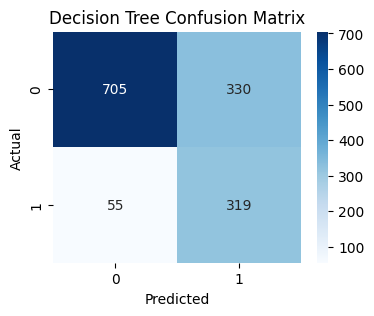

In [59]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

Visualize the tree using plot_tree() (max depth shown = 3 for readability). What is the root split feature?

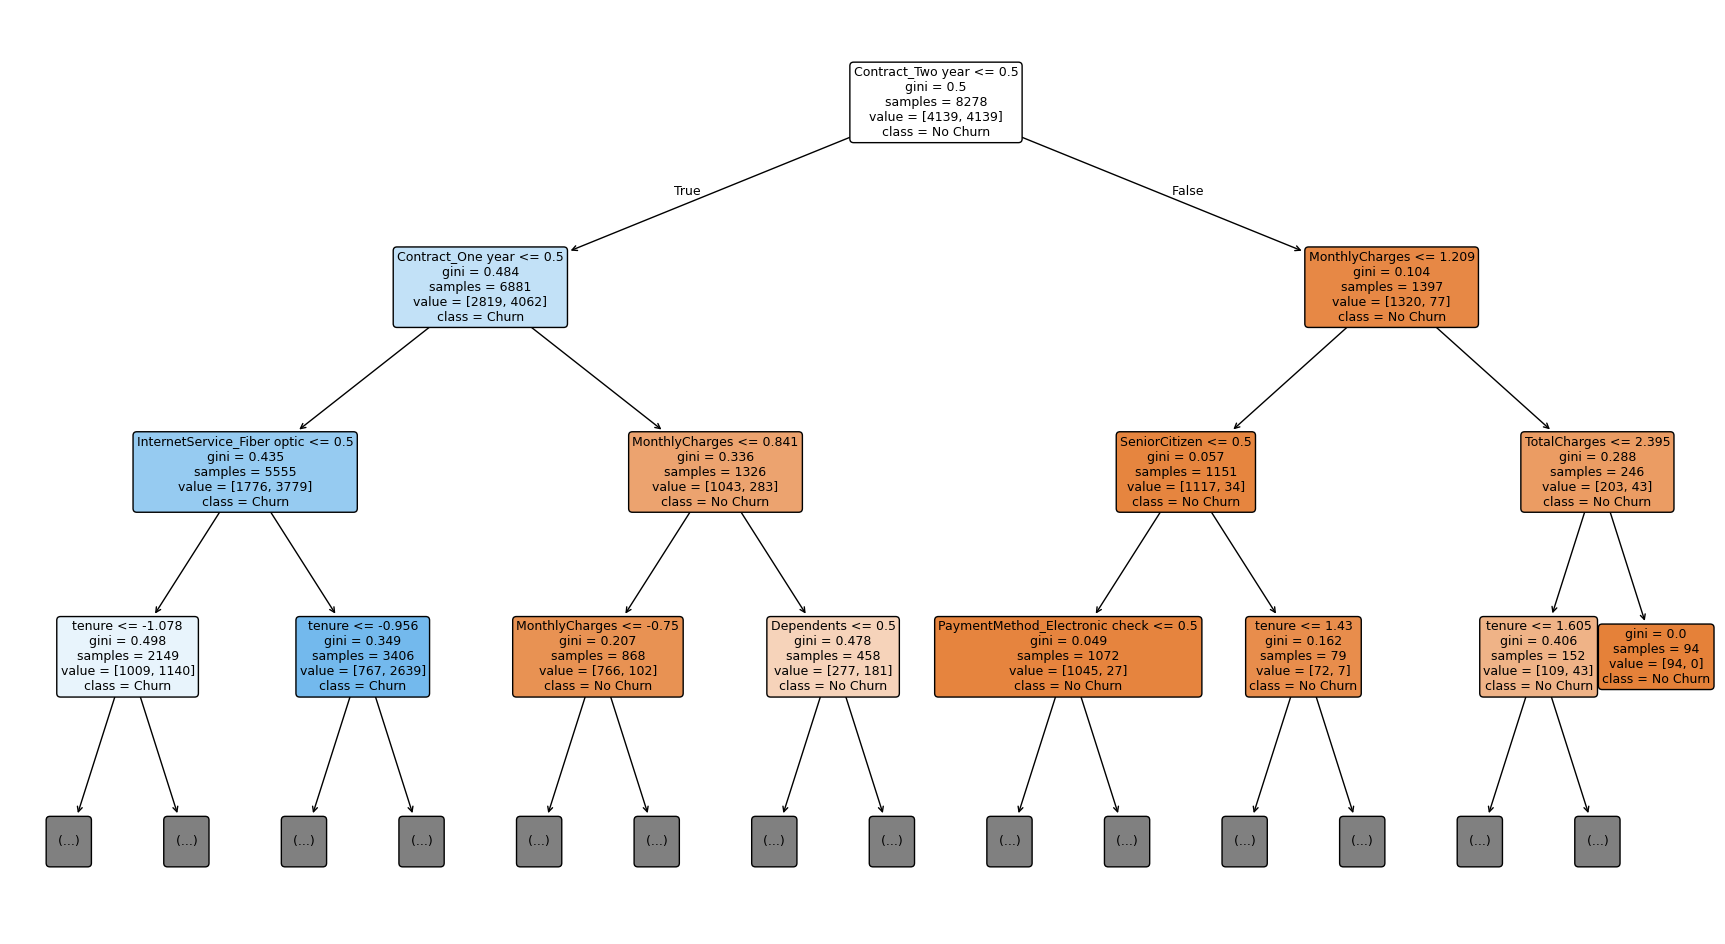

In [60]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22,12))
plot_tree(dt,feature_names=X_train.columns,class_names=['No Churn','Churn'],filled=True,rounded=True,max_depth=3,fontsize=9)
plt.show()

-Root Split Feature : Contract_Two year

Tune max_depth: Try depth = [3, 4, 5, 6, 7, 8, None] using cross_val_score (scoring='f1').

In [61]:
from sklearn.model_selection import cross_val_score

depths = [3,4,5,6,7,8,None]
f1_scores = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth,class_weight='balanced',random_state=42)
    scores = cross_val_score(model,X_train_smote,y_train_smote,cv=3,scoring='f1')
    f1_scores.append(scores.mean())

print(f1_scores)

[0.7795992333781085, 0.7704155204762085, 0.7711337234308487, 0.7903499866079174, 0.7785923165902617, 0.7809496179423743, 0.7555012851357655]


Plot depth vs F1.

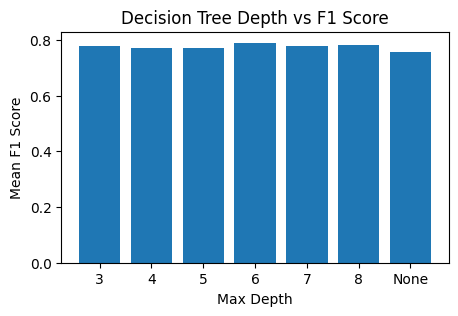

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))

depth_labels = ['3','4','5','6','7','8','None']

plt.bar(depth_labels,f1_scores)

plt.title("Decision Tree Depth vs F1 Score")
plt.xlabel("Max Depth")
plt.ylabel("Mean F1 Score")
plt.show()

Best depth

In [63]:
best_depth = depths[f1_scores.index(max(f1_scores))]

print('Best Depth =', best_depth)
print('F1 Score =', max(f1_scores))

Best Depth = 6
F1 Score = 0.7903499866079174


Re-train with best depth. 

In [64]:
best_dt = DecisionTreeClassifier(max_depth=best_depth,class_weight='balanced',random_state=42)

best_dt.fit(X_train_smote, y_train_smote)

y_pred = best_dt.predict(X_test)
y_prob = best_dt.predict_proba(X_test)[:,1]

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))
print('ROC AUC  :', roc_auc_score(y_test, y_prob))

Accuracy : 0.7345635202271115
Precision: 0.5
Recall   : 0.7887700534759359
F1 Score : 0.6120331950207469
ROC AUC  : 0.8211979126301377


Plot feature importances (top 15 features) as a sorted bar chart

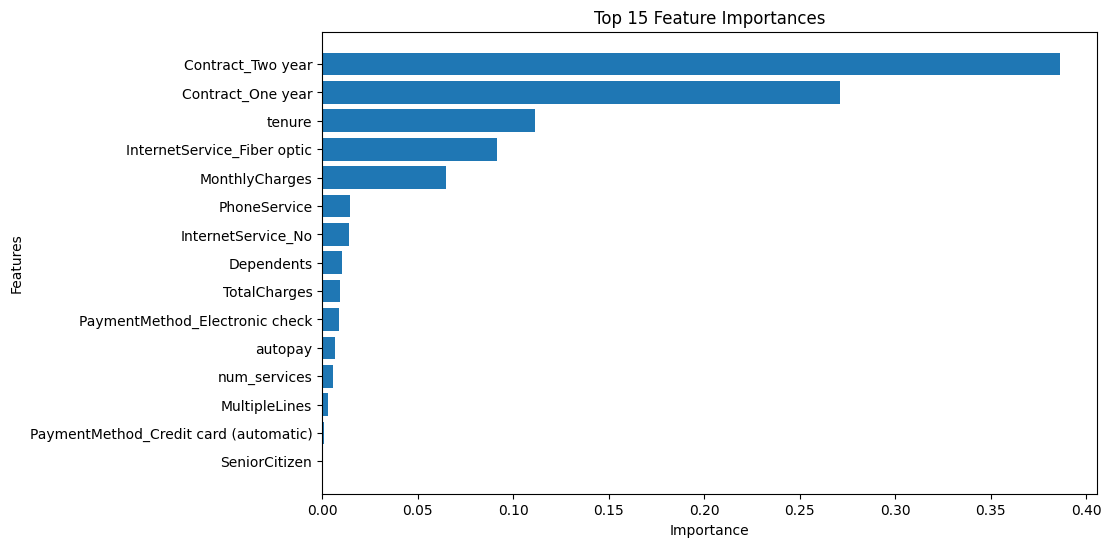

In [65]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dt.feature_importances_
})

importance = importance.sort_values(by='Importance',ascending=False)
top15 = importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15['Feature'],top15['Importance'])

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

* 5.3 One Model with class_weight='balanced' vs SMOTE: 

-Take your best-performing model so far. Train it twice: once on SMOTE-augmented data, once on original data with class_weight='balanced'.

#### Train on SMOTE Data

In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score

dt_smote = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

dt_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = dt_smote.predict(X_test)
recall_smote = recall_score(y_test, y_pred_smote)

print("Recall (SMOTE):", recall_smote)

Recall (SMOTE): 0.7887700534759359


#### Train on Original Data with class_weight='balanced'

In [67]:
dt_balanced = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight='balanced',
    random_state=42
)

dt_balanced.fit(X_train, y_train)
y_pred_balanced = dt_balanced.predict(X_test)
recall_balanced = recall_score(y_test, y_pred_balanced)

print("Recall (class_weight='balanced'):", recall_balanced)

Recall (class_weight='balanced'): 0.8074866310160428


-Compare Recall for the Churn class between the two approaches. Which gives better Recall?

In [68]:
print("Recall using SMOTE :", recall_smote)
print("Recall using class_weight=balanced:", recall_balanced)
print("\nclass_weight='balanced' gives better Recall.")

Recall using SMOTE : 0.7887700534759359
Recall using class_weight=balanced: 0.8074866310160428

class_weight='balanced' gives better Recall.


Create a consolidated comparison table of all 4 models

In [69]:
models = {'KNN': knn,'Gaussian NB': gnb,'SVM': best_svm,'Decision Tree': best_dt}
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Recall",
    ascending=False
)

comparison_df = comparison_df.round(4)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,Gaussian NB,0.7289,0.4934,0.7995,0.6102,0.8203
3,Decision Tree,0.7346,0.5000,0.7888,0.6120,0.8212
2,SVM,0.7232,0.4857,0.7273,0.5824,0.7875
0,KNN,0.7076,0.4665,0.7086,0.5626,0.7619


Plot all 4 ROC curves on a single figure with a legend.

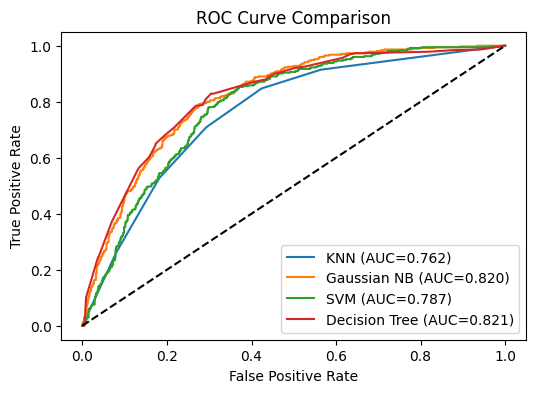

In [70]:
plt.figure(figsize=(6,4))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr,tpr,label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0,1],[0,1],linestyle="--",color="black")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Plot a grouped bar chart comparing Precision vs Recall for all 4 models side by side.


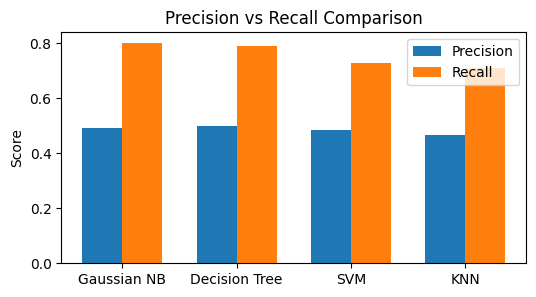

In [71]:
import numpy as np

x = np.arange(len(comparison_df))
width = 0.35
plt.figure(figsize=(6,3))

plt.bar(
    x-width/2,
    comparison_df["Precision"],
    width,
    label="Precision"
)

plt.bar(x+width/2,comparison_df["Recall"],width,label="Recall")
plt.xticks(
    x,
    comparison_df["Model"]
)

plt.ylabel("Score")
plt.title("Precision vs Recall Comparison")
plt.legend()
plt.show()

* Which model would you deploy for Jio/Airtel's retention team, and why? Consider Recall, interpretability, and latency. 

Among the four models, 'Gaussian NB' achieved the highest Recall for the churn class, making it the most suitable choice for customer retention. Since missing a true churner (False Negative) is more costly than contacting a customer who would not churn, Recall is the most important evaluation metric. Although Decision Trees provide better interpretability than SVM, SVM may offer higher predictive performance if its Recall is superior. Considering the business scenario where Jio or Airtel can contact only about 500 customers per day, Precision is also important to ensure that outreach efforts focus on customers who are genuinely at risk

* Step 7: Error Analysis & Interpretation: 

-7.1 Error Analysis on Best Model: 

From your best model's predictions, isolate all False Negatives (actual churners predicted as No Churn)

In [72]:
y_pred = best_dt.predict(X_test)

X_test_analysis = X_test.copy()
X_test_analysis["Actual"] = y_test.values
X_test_analysis["Predicted"] = y_pred

false_negatives = X_test_analysis[
    (X_test_analysis["Actual"] == 1) &
    (X_test_analysis["Predicted"] == 0)
]

print('False Negatives:', len(false_negatives))

False Negatives: 79


Profile the False Negatives: What is the average tenure, MonthlyCharges, and Contract type of these missed customers?

In [73]:
print("Average Tenure:")
print(false_negatives["tenure"].mean())

print("\nAverage Monthly Charges:")
print(false_negatives["MonthlyCharges"].mean())

def get_contract(row):
    if row["Contract_One year"] == 1:
        return "One Year"
    elif row["Contract_Two year"] == 1:
        return "Two Year"
    else:
        return "Month-to-Month"

false_negatives["Contract"] = false_negatives.apply(
    get_contract,
    axis=1
)

print('\n',false_negatives["Contract"].value_counts())

Average Tenure:
-0.07230273771815213

Average Monthly Charges:
0.05461970790729002

 Contract
Month-to-Month    37
One Year          33
Two Year           9
Name: count, dtype: int64


C:\Users\adity\AppData\Local\Temp\ipykernel_7916\1571833996.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false_negatives["Contract"] = false_negatives.apply(


Compare this profile to the overall churner profile.

In [74]:
overall_churners = X_test.copy()
overall_churners["Actual"] = y_test.values

overall_churners = overall_churners[
    overall_churners["Actual"] == 1
]

print("Average Tenure:")
print(overall_churners["tenure"].mean())

print("\nAverage Monthly Charges:")
print(overall_churners["MonthlyCharges"].mean())

overall_churners["Contract"] = overall_churners.apply(
    get_contract,
    axis=1
)

print('\n',overall_churners["Contract"].value_counts())

Average Tenure:
-0.6522086002374717

Average Monthly Charges:
0.2600643560851708

 Contract
Month-to-Month    329
One Year           36
Two Year            9
Name: count, dtype: int64


For your Decision Tree: list the top 5 split features and explain what each means for churn prediction.

In [75]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dt.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
top5 = feature_importance.head(5)

print(top5)

                        Feature  Importance
17            Contract_Two year    0.386220
16            Contract_One year    0.270914
4                        tenure    0.111375
14  InternetService_Fiber optic    0.091332
8                MonthlyCharges    0.064742


| Feature                         | Business Meaning                                                                                                         |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------ |
| **Contract_Two year**           | Customers with two-year contracts are much less likely to churn because they are committed for a longer period.          |
| **tenure**                      | Customers with longer tenure are generally more loyal and have a lower probability of churning.                          |
| **MonthlyCharges**              | Customers paying higher monthly charges are more likely to churn, especially if they perceive poor value.                |
| **TotalCharges**                | Higher total charges usually indicate long-term customers, who tend to have lower churn risk.                            |
| **InternetService_Fiber optic** | Fiber optic users often pay more for premium service and may churn if they are dissatisfied or find better alternatives. |


Write 3–5 business-friendly bullet points.

- Customers with Month-to-Month contracts are more likely to churn than customers with one-year or two-year contracts. 

- Customers with short tenure are at the highest risk of leaving, suggesting that retention efforts should focus on new customers. 

- Customers paying higher monthly charges show a greater likelihood of churn, indicating that pricing and perceived value influence customer retention.